In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [2]:
import os
import gc

import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from transformers import AutoFeatureExtractor, AutoModelForSpeechSeq2Seq

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_predict
from scipy.stats import pearsonr

# ----- Paths (Kaggle) -----
BASE      = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
TRAIN_DIR = f"{BASE}/train"
TEST_DIR  = f"{BASE}/test"
OUT_DIR   = "/kaggle/working"

# ----- Model / feature settings -----
WHISPER_ID = "openai/whisper-large-v3-turbo"   # only its ENCODER is used
LAYERS     = [16, 24, 32]                      # encoder layers whose outputs are pooled
SR         = 16000                             # Whisper expects 16 kHz audio
WIN        = 30 * SR                           # encoder input window = 30 s
FRAMES_PS  = 50                                # encoder frames per second of audio

SEED   = 42
RUN_CV = True    # 5-fold CV for reporting only (does not affect the final model)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if torch.cuda.is_available() else torch.float32
print("Device:", device, "| dtype:", dtype)


def rmse(a, b):
    # Root-mean-squared error.
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def audio_path(folder, name):
    # Build the full .wav path (works whether or not the name has the extension).
    name = str(name)
    return os.path.join(folder, name if name.endswith(".wav") else name + ".wav")

Device: cuda:0 | dtype: torch.float16


train: (769, 2) | test: (216, 2)
count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Name: label, dtype: float64

Mean-predictor RMSE (baseline to beat): 1.2382


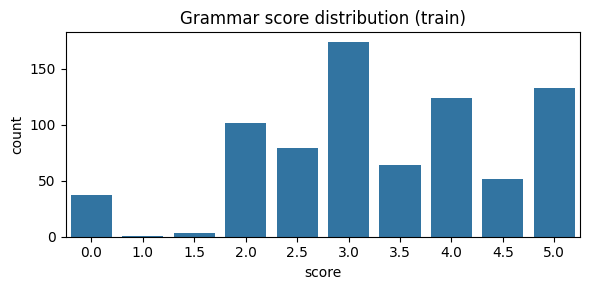

In [3]:
train_df = pd.read_csv(f"{BASE}/train.csv")   # columns: filename, label
test_df  = pd.read_csv(f"{BASE}/test.csv")    # labels here are dummy (-1) and are NOT used

y = train_df["label"].values.astype(float)
print("train:", train_df.shape, "| test:", test_df.shape)
print(train_df["label"].describe().round(3))
print("\nMean-predictor RMSE (baseline to beat):", round(rmse(y, np.full_like(y, y.mean())), 4))

plt.figure(figsize=(6, 3))
sns.countplot(x=train_df["label"])
plt.title("Grammar score distribution (train)")
plt.xlabel("score"); plt.ylabel("count")
plt.tight_layout(); plt.show()

In [4]:
feature_extractor = AutoFeatureExtractor.from_pretrained(WHISPER_ID)   # log-mel front end

_full_model = AutoModelForSpeechSeq2Seq.from_pretrained(WHISPER_ID, dtype=dtype)
encoder = _full_model.get_encoder().to(device).eval()
del _full_model; gc.collect()
if device != "cpu":
    torch.cuda.empty_cache()

print("Encoder loaded | hidden size:", encoder.config.d_model)

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.62GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

Encoder loaded | hidden size: 1280


In [5]:
@torch.no_grad()
def whisper_embed(path):
    # Return one fixed-length embedding (len(LAYERS) * 1280 values) for an audio file.
    wav, _ = librosa.load(path, sr=SR, mono=True)

    # 30 s windows; drop tails shorter than 1 s (fall back to the whole clip if all are that short)
    chunks = [wav[i:i + WIN] for i in range(0, len(wav), WIN)]
    chunks = [c for c in chunks if len(c) >= SR] or [wav]

    vecs, weights = [], []
    for chunk in chunks:
        feats = feature_extractor(chunk, sampling_rate=SR, return_tensors="pt").input_features
        hidden = encoder(feats.to(device, dtype), output_hidden_states=True).hidden_states

        # frames that correspond to real audio (the rest of the 30 s window is zero padding)
        n_valid = max(1, int(len(chunk) / SR * FRAMES_PS))

        # mean over time for each selected layer, then concatenate the layers
        vec = torch.cat([hidden[l][0, :n_valid].float().mean(dim=0) for l in LAYERS])
        vecs.append(vec.cpu().numpy())
        weights.append(n_valid)

    # average the windows, weighted by how much real audio each contains
    return np.average(vecs, axis=0, weights=weights)

In [6]:
def extract_embeddings(filenames, folder, cache_file, desc):
    # Embed every file (or load from cache if already computed).
    cache_path = os.path.join(OUT_DIR, cache_file)
    if os.path.exists(cache_path):
        emb = np.load(cache_path)
        if len(emb) == len(filenames):
            print(f"Loaded cached embeddings: {cache_file} {emb.shape}")
            return emb
    emb = np.stack([whisper_embed(audio_path(folder, f)) for f in tqdm(filenames, desc=desc)])
    np.save(cache_path, emb)
    return emb


E_train = extract_embeddings(train_df["filename"].tolist(), TRAIN_DIR, "E_train.npy", "train embeddings")
E_test  = extract_embeddings(test_df["filename"].tolist(),  TEST_DIR,  "E_test.npy",  "test embeddings")

assert not np.isnan(E_train).any() and not np.isnan(E_test).any(), "NaNs in embeddings"
print("E_train:", E_train.shape, "| E_test:", E_test.shape)

# the encoder is no longer needed -> free GPU memory
del encoder; gc.collect()
if device != "cpu":
    torch.cuda.empty_cache()

train embeddings:   0%|          | 0/769 [00:00<?, ?it/s]

test embeddings:   0%|          | 0/216 [00:00<?, ?it/s]

E_train: (769, 3840) | E_test: (216, 3840)


In [7]:
def make_models():
    # Fresh (unfitted) copies of the two regressors.
    return {
        # Linear model; RidgeCV picks the regularisation strength itself (efficient leave-one-out)
        "ridge": make_pipeline(StandardScaler(),
                               RidgeCV(alphas=np.logspace(2, 5, 12))),
        # Non-linear RBF support-vector regressor
        "svr":   make_pipeline(StandardScaler(),
                               SVR(C=2.0, epsilon=0.2, gamma="scale")),
    }


def blend_predict(models, X):
    # Average of the individual models' predictions, each clipped to [0, 5].
    return np.mean([np.clip(m.predict(X), 0, 5) for m in models.values()], axis=0)

model                  CV RMSE  CV Pearson
ridge                   0.5492      0.8966
svr                     0.5581      0.8957
blend (ridge+svr)       0.5366      0.9034


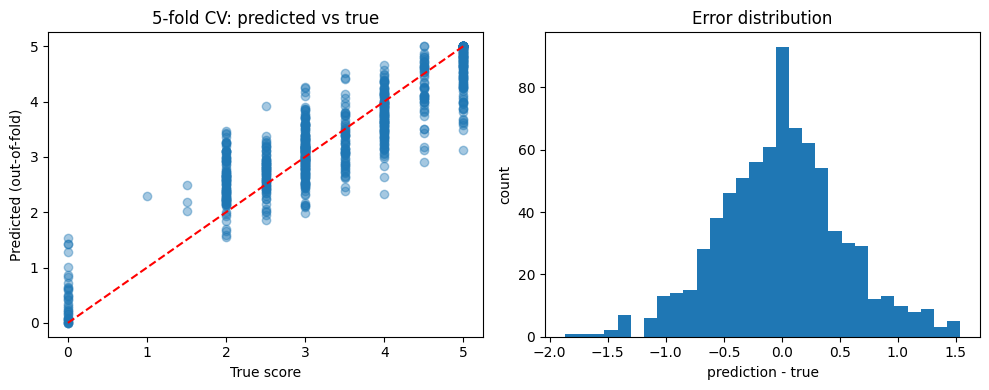


CV RMSE by true score:
        n   rmse
true            
0.0    37  0.619
1.0     1  1.298
1.5     3  0.759
2.0   102  0.714
2.5    79  0.417
3.0   174  0.438
3.5    64  0.515
4.0   124  0.490
4.5    52  0.545
5.0   133  0.565


In [8]:
if RUN_CV:
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

    # out-of-fold predictions: every sample is predicted by a model that never saw it
    oof = {name: np.clip(cross_val_predict(m, E_train, y, cv=kf), 0, 5)
           for name, m in make_models().items()}
    oof["blend (ridge+svr)"] = np.mean([oof["ridge"], oof["svr"]], axis=0)

    print(f"{'model':20s} {'CV RMSE':>9s} {'CV Pearson':>11s}")
    for name, p in oof.items():
        print(f"{name:20s} {rmse(y, p):9.4f} {pearsonr(y, p)[0]:11.4f}")

    p = oof["blend (ridge+svr)"]

    # Plots: predicted vs true, and the error distribution
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].scatter(y, p, alpha=0.4)
    ax[0].plot([0, 5], [0, 5], "r--")
    ax[0].set(xlabel="True score", ylabel="Predicted (out-of-fold)", title="5-fold CV: predicted vs true")
    ax[1].hist(p - y, bins=30)
    ax[1].set(xlabel="prediction - true", ylabel="count", title="Error distribution")
    plt.tight_layout(); plt.show()

    # Where does the error sit? (per true score)
    err = pd.DataFrame({"true": y, "sq_err": (y - p) ** 2})
    print("\nCV RMSE by true score:")
    print(err.groupby("true")["sq_err"].agg(n="count", rmse=lambda s: np.sqrt(s.mean())).round(3))

RidgeCV selected alpha: 351.1

==================== FINAL TRAINING METRICS ====================
TRAIN RMSE    : 0.2369
TRAIN Pearson : 0.9839
(Training RMSE is optimistic; see the 5-fold CV RMSE in Step 7 for generalisation.)


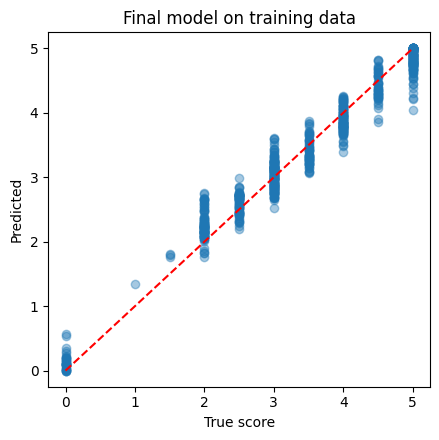

In [9]:
final_models = make_models()
for name, m in final_models.items():
    m.fit(E_train, y)                                   # all 769 training samples

print("RidgeCV selected alpha:", round(float(final_models["ridge"][-1].alpha_), 1))

# ----- Predictions of the final (blended) model -----
train_pred = blend_predict(final_models, E_train)
test_pred  = blend_predict(final_models, E_test)

# ----- Compulsory training metrics -----
print("\n==================== FINAL TRAINING METRICS ====================")
print(f"TRAIN RMSE    : {rmse(y, train_pred):.4f}")
print(f"TRAIN Pearson : {pearsonr(y, train_pred)[0]:.4f}")
print("================================================================")
print("(Training RMSE is optimistic; see the 5-fold CV RMSE in Step 7 for generalisation.)")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(y, train_pred, alpha=0.4)
plt.plot([0, 5], [0, 5], "r--")
plt.xlabel("True score"); plt.ylabel("Predicted"); plt.title("Final model on training data")
plt.tight_layout(); plt.show()

        filename     label
0  audio_128.wav  3.030542
1  audio_156.wav  4.222906
2   audio_19.wav  4.490402
3  audio_108.wav  2.113443
4  audio_206.wav  2.385711

Prediction summary:
 count    216.000
mean       3.294
std        0.794
min        1.732
25%        2.711
50%        3.240
75%        3.685
max        5.000
Name: label, dtype: float64


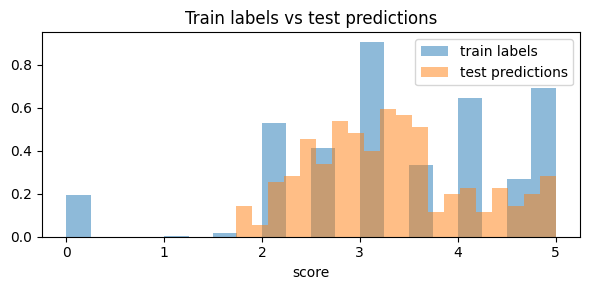

In [10]:
submission = pd.DataFrame({"filename": test_df["filename"], "label": test_pred})

# sanity checks before saving
assert len(submission) == len(test_df) == 216,          "unexpected number of rows"
assert submission["label"].notna().all(),               "missing predictions"
assert submission["filename"].is_unique,                "duplicate filenames"
assert submission["label"].between(0, 5).all(),         "predictions outside [0, 5]"

submission.to_csv(f"{OUT_DIR}/submission.csv", index=False)
print(submission.head())
print("\nPrediction summary:\n", submission["label"].describe().round(3))

# compare predicted test distribution with the training label distribution
plt.figure(figsize=(6, 3))
plt.hist(y, bins=20, alpha=0.5, density=True, label="train labels")
plt.hist(test_pred, bins=20, alpha=0.5, density=True, label="test predictions")
plt.xlabel("score"); plt.legend(); plt.title("Train labels vs test predictions")
plt.tight_layout(); plt.show()